In [1]:
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, Isomap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import load_iris
import time
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Clustering

## Description of the dataset

In [54]:
def plot_2d_data(data, labels, title='Initial data', ax=None, scale=None):
    n_clusters = np.unique(labels).size
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    else:
        fig = None
        
    scatter = ax.scatter(data[:, 0], data[:, 1], c=labels, s = scale)

    cbar = plt.colorbar(scatter, label='Number of clusters', ax=ax)
    cbar.set_ticks(np.min(labels) + (np.arange(n_clusters) + 0.5) * (n_clusters - 1) / n_clusters)
    cbar.set_ticklabels(np.unique(labels))

    ax.set_title(title)
    ax.grid(True)

In [4]:
X, y = load_iris(return_X_y=True)
iris = load_iris(as_frame=True)
df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

In [5]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [6]:
plt.style.use("ggplot")
plt.rcParams['figure.dpi'] = 100

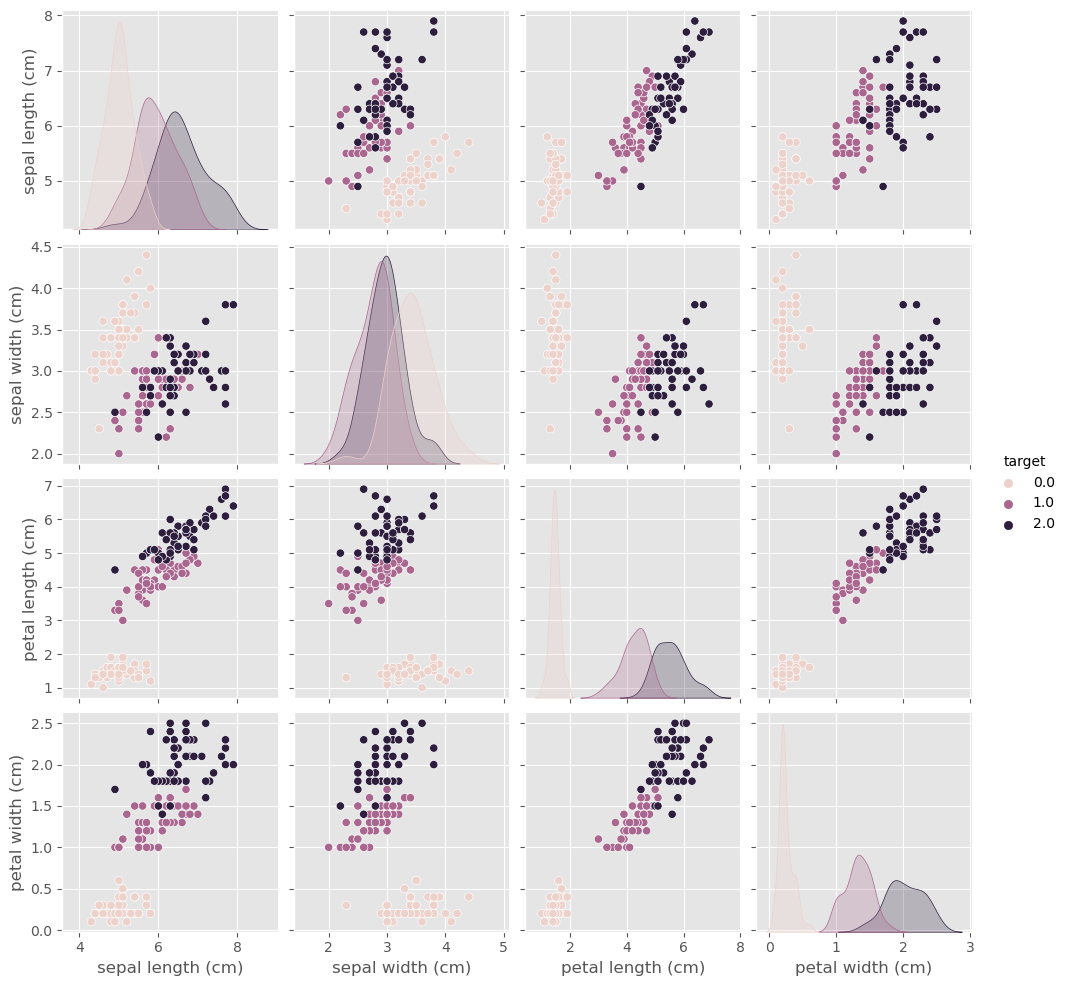

In [7]:
sns.pairplot(df , hue = 'target')
plt.savefig("pairplot.png")

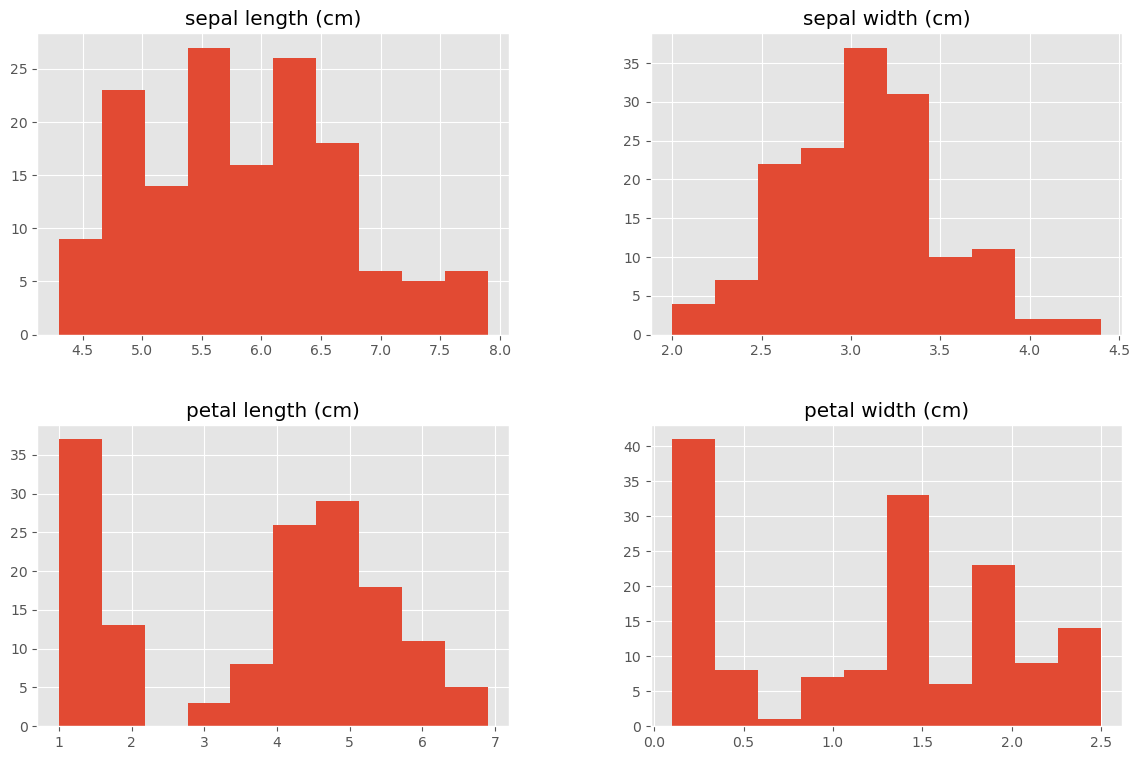

In [8]:
df[df.columns[:4]].hist(figsize=(14, 9));

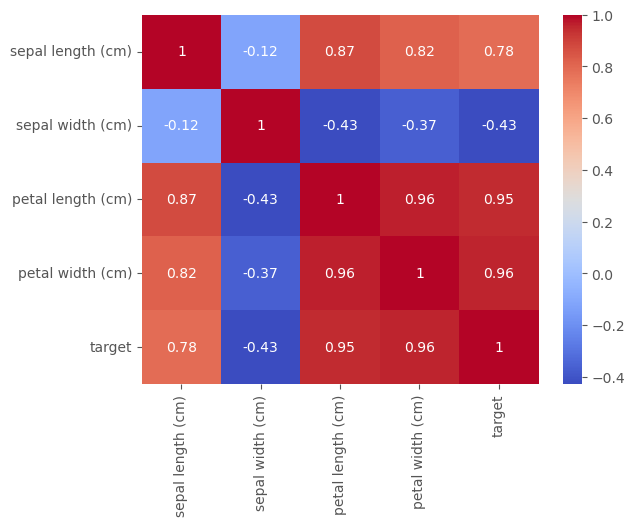

In [9]:
sns.heatmap(df.corr(),annot=True,  cmap='coolwarm');
plt.savefig("heatmap.png")

# KMeans

In [10]:
pip install threadpoolctl==3.1.0

Note: you may need to restart the kernel to use updated packages.


In [11]:
labels_KMeans = KMeans(n_clusters=3).fit_predict(X)

# TSNE

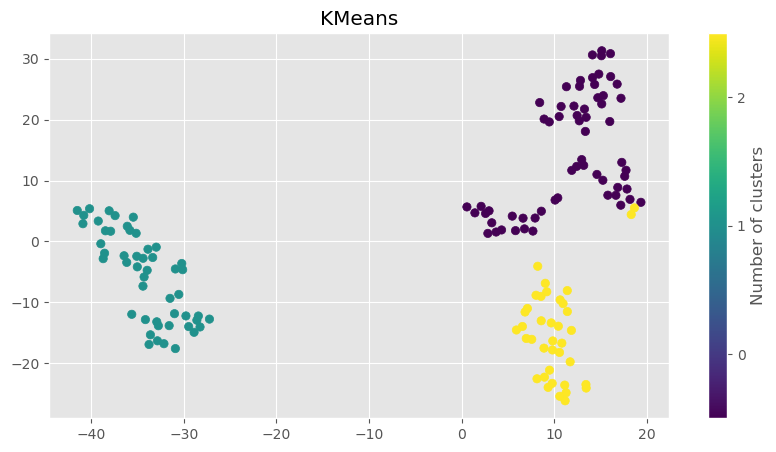

In [12]:
TSNE_model = TSNE(n_components=2,
                  perplexity=10.0, 
                  early_exaggeration=10.0)
X_TSNE = TSNE_model.fit_transform(X)

plot_2d_data(X_TSNE, labels_KMeans, title = "KMeans")

plt.savefig("KMeans_plot.png")

# DBSCAN

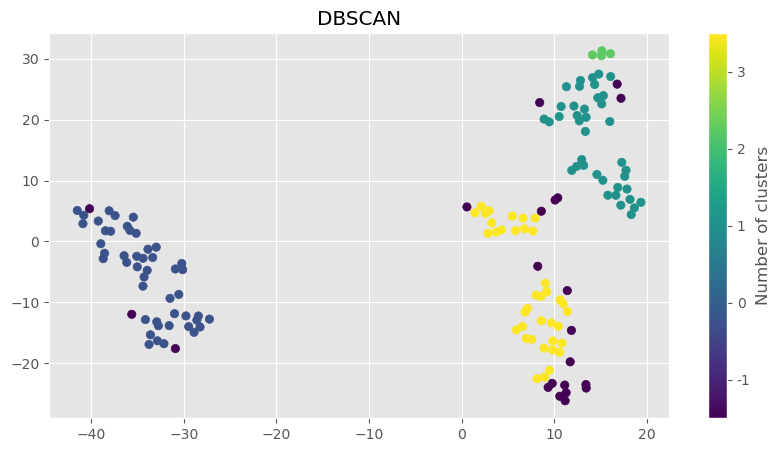

In [13]:
labels_DBSCAN = DBSCAN(eps=0.4, min_samples=3).fit_predict(X)

plot_2d_data(X_TSNE, labels_DBSCAN, title = "DBSCAN")

plt.savefig("DBSCAN_plot.png")

# AgglomerativeClustering

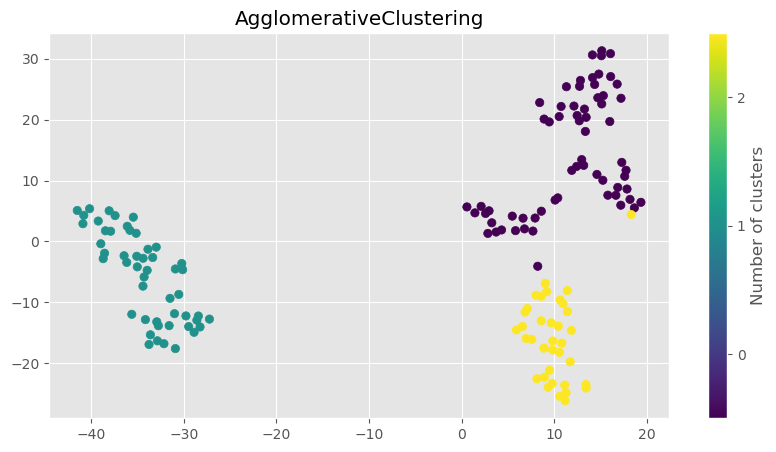

In [14]:
labels_AggClust = AgglomerativeClustering(n_clusters=3).fit_predict(X)

plot_2d_data(X_TSNE, labels_AggClust, title = "AgglomerativeClustering")

plt.savefig("AgglomerativeClustering_plot.png")

# Regression

## Description of the dataset

In [15]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X, y  = fetch_california_housing(return_X_y=True)


In [16]:
df = pd.DataFrame(data= np.c_[housing['data'], housing['target']],
                     columns= housing['feature_names'] + ['target'])

In [17]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


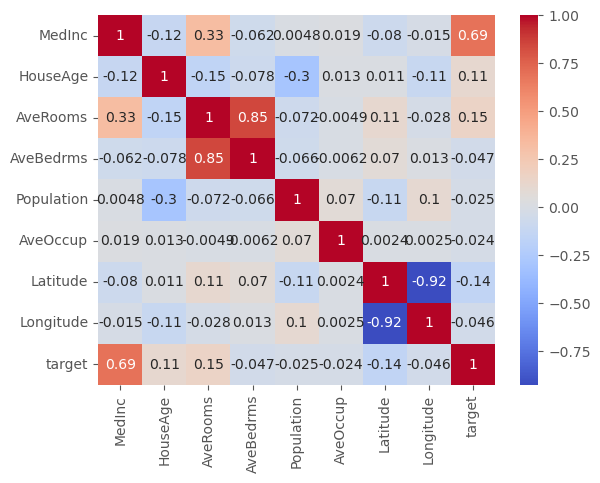

In [18]:
sns.heatmap(df.corr(),annot=True,  cmap='coolwarm');

## Validation curve

In [19]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

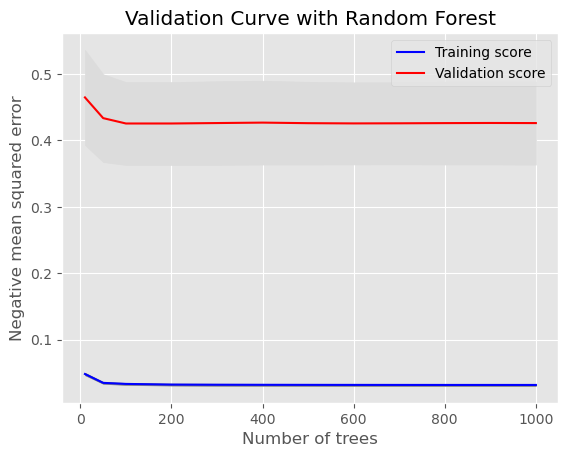

Optimal number of estimators: 100


In [20]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

california = fetch_california_housing()

param_range = [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

train_scores, test_scores = validation_curve(RandomForestRegressor(random_state=42), california.data, california.target, param_name="n_estimators", param_range=param_range, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)

train_mean = -train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = -test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

best_n_estimators = param_range[np.argmin(test_mean)]

plt.plot(param_range, train_mean, label="Training score", color="blue")
plt.plot(param_range, test_mean, label="Validation score", color="red")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="gray")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="gainsboro")

plt.title("Validation Curve with Random Forest")
plt.xlabel("Number of trees")
plt.ylabel("Negative mean squared error")
plt.legend(loc="best")
plt.show()

print("Optimal number of estimators:", best_n_estimators)

# Random Forest

In [21]:
model = RandomForestRegressor(n_estimators=100,max_depth= 15,  random_state=42)
model.fit(X_train,y_train)

y_predict = model.predict(X_test)

**RMSE**

In [22]:
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, y_predict, squared = False)
rmse

0.5089881112380351

**R^2**

In [23]:
r2_score(y_predict, y_test)

0.744942490439954

**MAE**

In [24]:
def mae(test, predict, n):
  return np.sum(np.abs(test - predict)/n)

In [25]:
import time
from tqdm import tqdm

n_est_list = np.int_(np.logspace(1, 2, num=5))
time_list, mae_test_list, mae_train_list = [], [], []

for num in tqdm(n_est_list):
  model = RandomForestRegressor(n_estimators=num, random_state=42)
  
  start = time.time()
  model.fit(X_train,y_train)
  time_list.append(time.time() - start)
  
  y_predict = model.predict(X_test)
  mae_test_list.append(mae(y_test, y_predict, len(y_test)))
  
  y_predict = model.predict(X_train)
  mae_train_list.append(mae(y_train, y_predict, len(y_train)))

100%|█████████████████████████████████████████████| 5/5 [00:16<00:00,  3.29s/it]


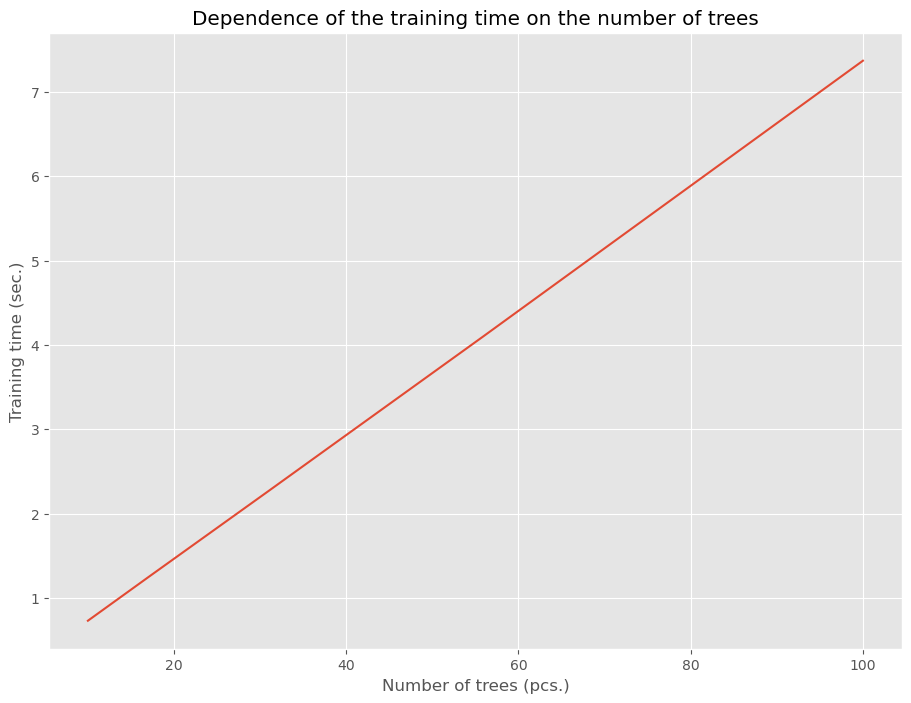

In [26]:
plt.style.use('ggplot')
plt.figure(figsize=(11, 8))
plt.plot(n_est_list, time_list)
plt.xlabel("Number of trees (pcs.)")
plt.ylabel("Training time (sec.)")
plt.title("Dependence of the training time on the number of trees");

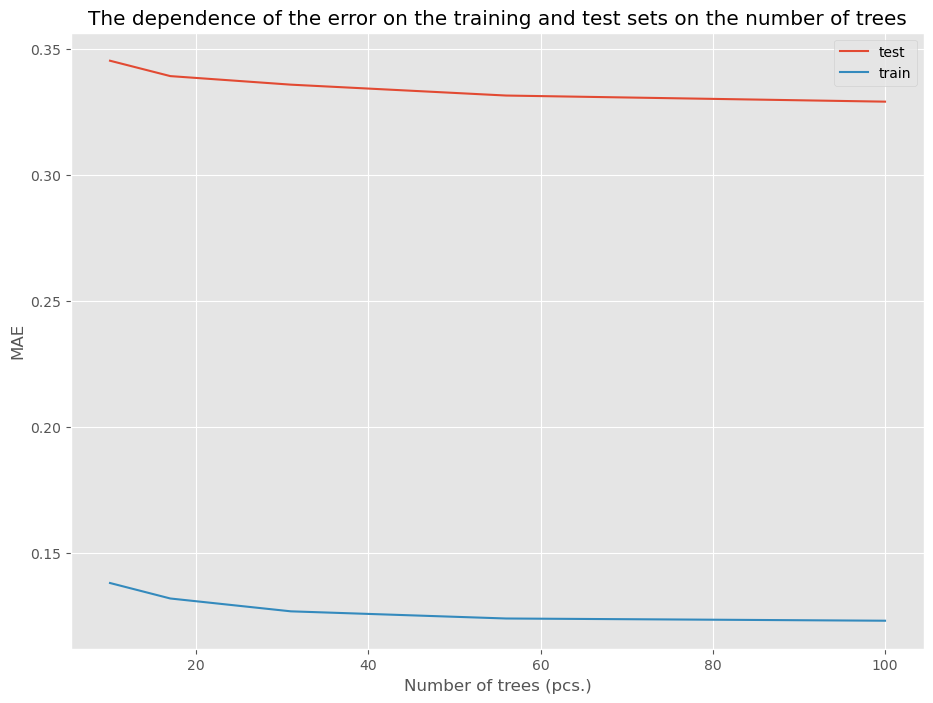

In [27]:
plt.style.use('ggplot')
plt.figure(figsize=(11, 8))
plt.plot(n_est_list, mae_test_list, label="test")
plt.plot(n_est_list, mae_train_list, label="train")
plt.xlabel("Number of trees (pcs.)")
plt.ylabel("MAE")
plt.title("The dependence of the error on the training and test sets on the number of trees")
plt.legend();

In [28]:
mae_list, fit_time = [], []
n_estimators = [i * 10 for i in range(1, 9)]

model = RandomForestRegressor( n_estimators = 10, 
                              warm_start = True,
                              random_state=42)

for num in tqdm(n_estimators):

  model.n_estimators = num
  
  start = time.time()
  model.fit(X_train,y_train)
  fit_time.append(time.time() - start)
  
  y_predict = model.predict(X_test)
  mae_list.append(mae(y_test, y_predict, len(y_test)))

100%|█████████████████████████████████████████████| 8/8 [00:06<00:00,  1.29it/s]


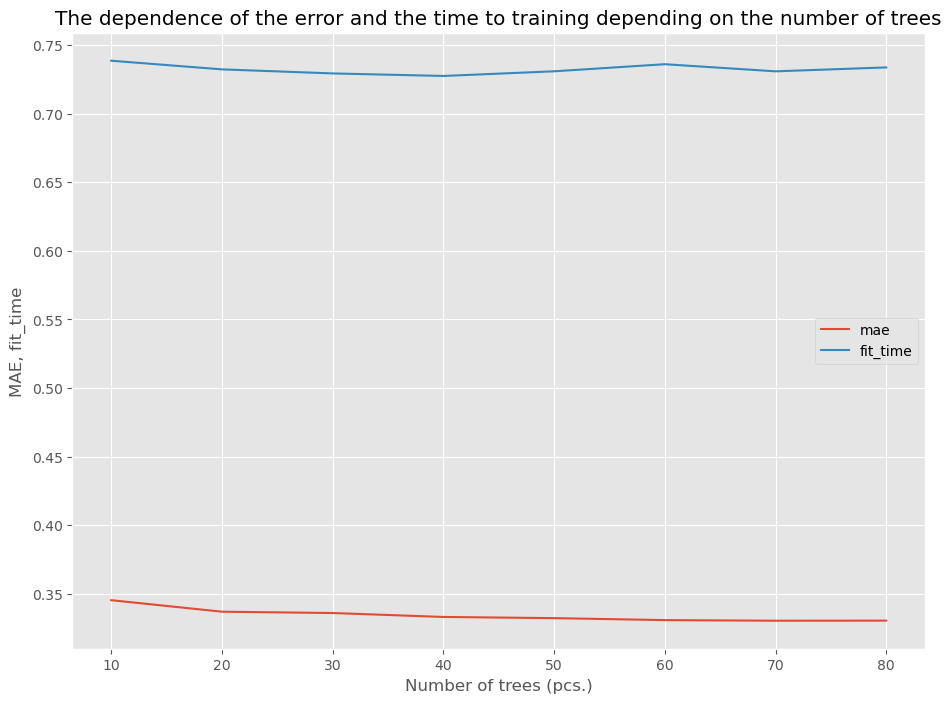

In [29]:
plt.style.use('ggplot')
plt.figure(figsize=(11, 8))
plt.plot(n_estimators, mae_list, label="mae")
plt.plot(n_estimators, fit_time, label="fit_time")
plt.xlabel("Number of trees (pcs.)")
plt.ylabel("MAE, fit_time")
plt.title("The dependence of the error and the time to training depending on the number of trees")
plt.legend();

In [30]:
plt.style.use("ggplot")
plt.rcParams['figure.dpi'] = 150

**Decision tree**

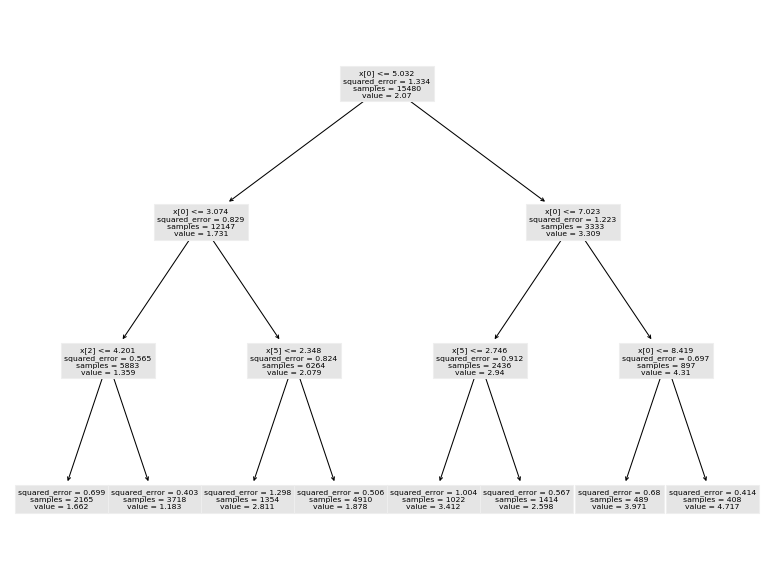

In [31]:
decision_tree_regressor = DecisionTreeRegressor(max_depth=3, random_state=0)
clf = decision_tree_regressor.fit(X_train,y_train)
y_predict = decision_tree_regressor.predict(X_test)

plot_tree(clf);

plt.savefig("tree_graph.png")

## Gradient boosting

In [32]:
test_parameters = {"n_estimators": 1000, "max_depth": 5, "learning_rate":0.1}

In [33]:
GBR = GradientBoostingRegressor(**test_parameters)
GBR.fit(X_train, y_train)
predict = GBR.predict(X_test)

In [34]:
rmse = mean_squared_error(predict,y_test, squared = False)
rmse

0.44961459806946064

In [35]:
r2_score(predict, y_test)

0.822065111776688

# Classification

In [36]:
X, y = fetch_openml(
    "mnist_784", version=1, return_X_y=True, as_frame=False, parser="pandas"
)

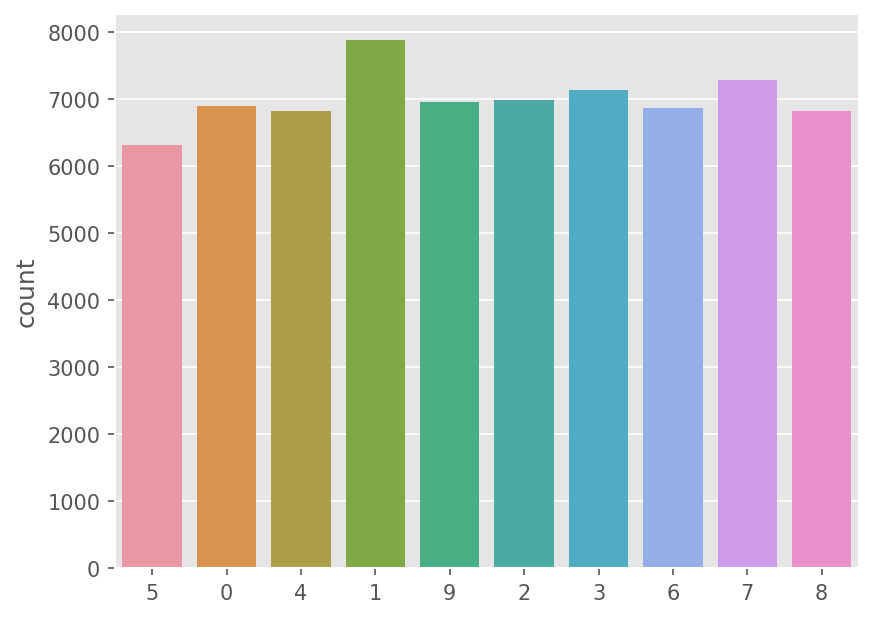

In [37]:
sns.countplot(x=y);

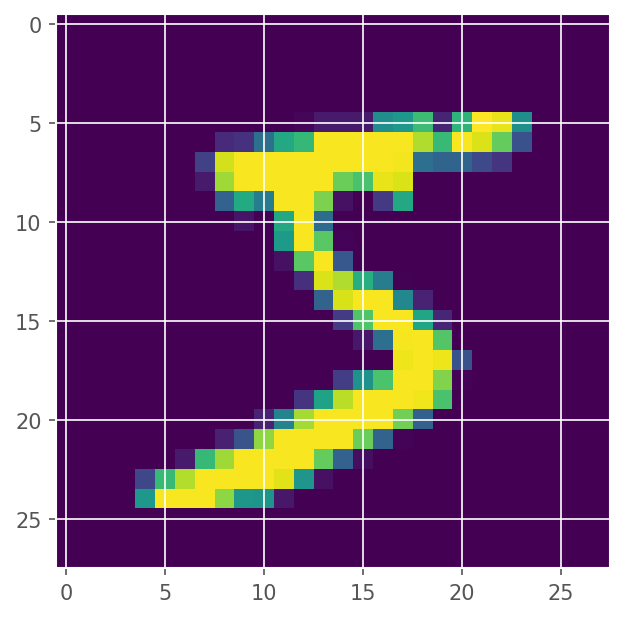

In [38]:
plt.imshow(X[0].reshape((28, 28)));
plt.savefig("digit.png")

# Logistic regression

In [39]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True )

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(solver="saga", tol=0.1)
clf.fit(X_train, y_train)
predict = clf.predict(X_test)

In [40]:
accuracy_score(predict, y_test)

0.8864285714285715

In [53]:
import numpy as np

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True )

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [42]:
clf = LogisticRegression(solver="saga", tol=0.1)
clf.fit(x_train, y_train)
predict = clf.predict(x_test)

In [43]:
accuracy_score(predict, y_test)

0.9265714285714286

# Random forest

In [46]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

mnist = load_digits()

X, y = mnist["data"], mnist["target"].astype(np.uint8)

rf = RandomForestClassifier(random_state=42)
estimator_range = range(10, 101, 10)

scores = []
for estimator in estimator_range:
    rf.n_estimators = estimator
    score = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
    scores.append(score.mean())

for i in range(len(estimator_range)):
    print("Estimators:", estimator_range[i], "Accuracy:", scores[i])


Estimators: 10 Accuracy: 0.9087666357164963
Estimators: 20 Accuracy: 0.9321309192200558
Estimators: 30 Accuracy: 0.937137109254101
Estimators: 40 Accuracy: 0.9399226245744352
Estimators: 50 Accuracy: 0.9399226245744352
Estimators: 60 Accuracy: 0.9388084184463015
Estimators: 70 Accuracy: 0.9415923862581244
Estimators: 80 Accuracy: 0.9382528628907458
Estimators: 90 Accuracy: 0.9382497678737233
Estimators: 100 Accuracy: 0.9393639740018569


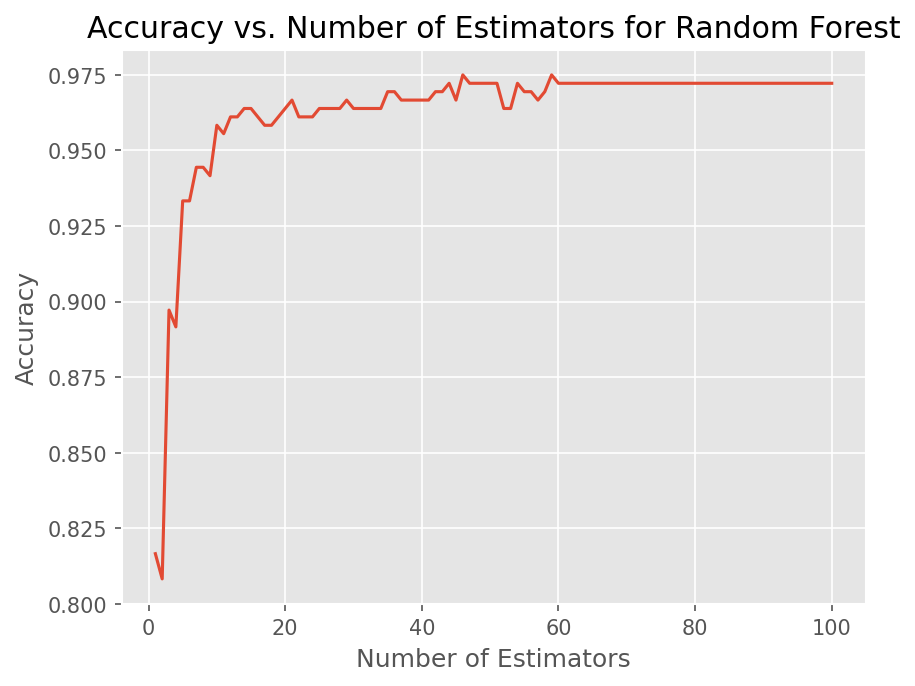

In [51]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

mnist = load_digits()
X = mnist.data
y = mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

estimators_range = range(1, 101)
accuracy_scores = []
for n_estimators in estimators_range:
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.plot(estimators_range, accuracy_scores)
plt.title('Accuracy vs. Number of Estimators for Random Forest')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.show()

# KNN

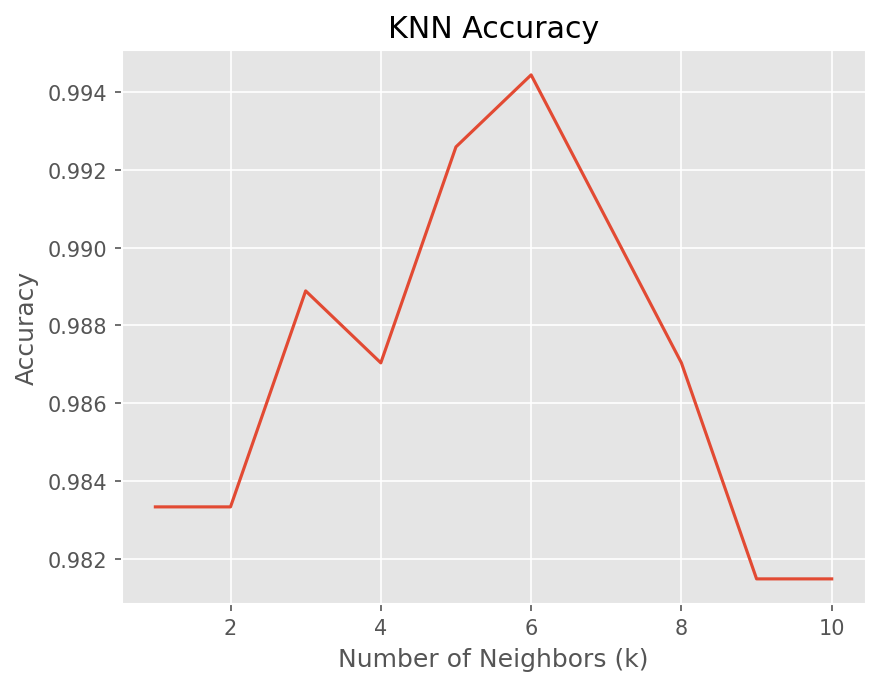

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

digits = load_digits()

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3, random_state=42)

accuracy_list = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)

plt.plot(range(1, 11), accuracy_list)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy')
plt.show()

# Comparing the accuracy of different models

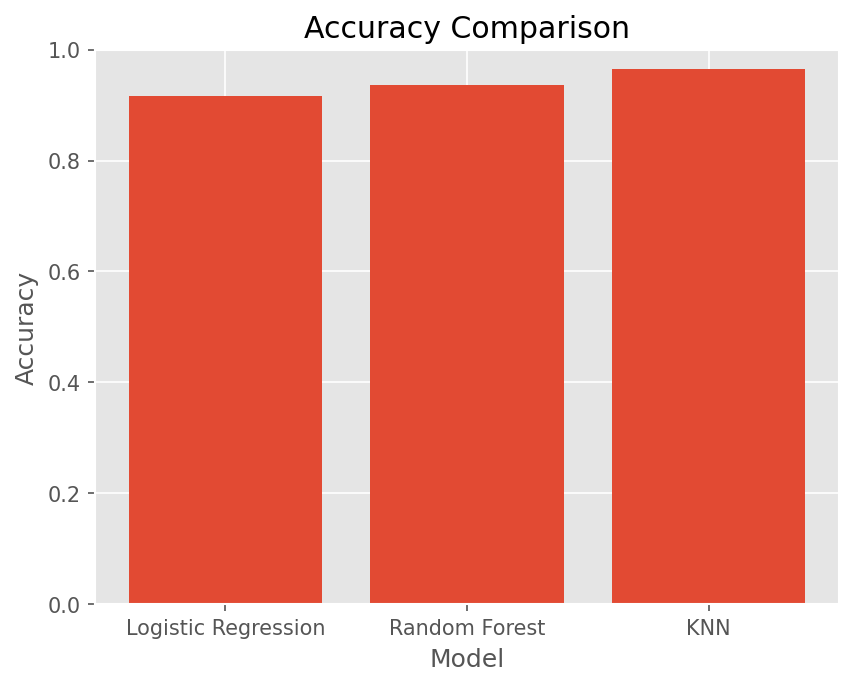

In [52]:
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

digits = load_digits()

train_size = 1200
train_images = digits.images[:train_size]
train_labels = digits.target[:train_size]
test_images = digits.images[train_size:]
test_labels = digits.target[train_size:]

lr = LogisticRegression(max_iter=10000)
lr.fit(train_images.reshape(-1, 64), train_labels)

rf = RandomForestClassifier(n_estimators=50)
rf.fit(train_images.reshape(-1, 64), train_labels)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_images.reshape(-1, 64), train_labels)

lr_preds = lr.predict(test_images.reshape(-1, 64))
rf_preds = rf.predict(test_images.reshape(-1, 64))
knn_preds = knn.predict(test_images.reshape(-1, 64))

lr_acc = accuracy_score(test_labels, lr_preds)
rf_acc = accuracy_score(test_labels, rf_preds)
knn_acc = accuracy_score(test_labels, knn_preds)

models = ['Logistic Regression', 'Random Forest', 'KNN']
accuracies = [lr_acc, rf_acc, knn_acc]
plt.bar(models, accuracies)
plt.title('Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()